<a href="https://colab.research.google.com/github/sathwikdbhat/IOT-Class/blob/master/Generative_AI_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Explore pre-trained word vectors. Explore word relationships using vector arithmetic. Perform arithmetic operations and analyze results.

In [ ]:
import gensim.downloader as api

# 1. Load the model (Google News is standard for VTU labs)
print("Loading model...")
model = api.load("word2vec-google-news-300")

# 2. Find Similar Words
print("\nSimilar to 'king':", model.most_similar("king", topn=5))

# 3. Word Arithmetic (King - Man + Woman = Queen)
# Rule: positive=[word1, word2], negative=[word3]
res = model.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)
print(f"\nking - man + woman = {res[0][0]}")

# 4. Check Similarity Score
sim = model.similarity("king", "queen")
print(f"\nSimilarity (king, queen): {sim:.4f}")

# 5. Odd One Out
words = ["apple", "banana", "grape", "car"]
print(f"\nOdd one out: {model.doesnt_match(words)}")

Loading model...

Similar to 'king': [('kings', 0.7138045430183411), ('queen', 0.6510956883430481), ('monarch', 0.6413194537162781), ('crown_prince', 0.6204220056533813), ('prince', 0.6159993410110474)]

king - man + woman = queen

Similarity (king, queen): 0.6511

Odd one out: car


2. Use dimensionality reduction (e.g., PCA or t-SNE) to visualize word embeddings for Q 1. Select 10 words from a specific domain (e.g., sports, technology) and visualize their embeddings. Analyze clusters and relationships. Generate contextually rich outputs using embeddings. Write a program to generate 5 semantically similar words for a given input.

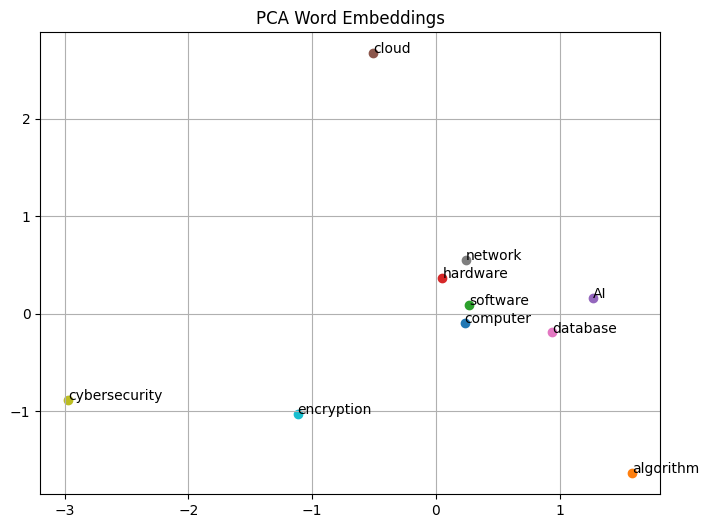


Similar to 'AI': [('Steven_Spielberg_Artificial_Intelligence', 0.5575934052467346), ('Index_MDE_##/###/####', 0.5415324568748474), ('Enemy_AI', 0.5256390571594238), ('Ace_Combat_Zero', 0.522663414478302), ('DOA4', 0.5182536244392395)]


In [ ]:
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Load Model (Same as Q1)
model = api.load("word2vec-google-news-300")

# 2. Select 10 words from a domain (Technology)
words = ["computer", "algorithm", "software", "hardware", "AI", "cloud", "database", "network", "cybersecurity", "encryption"]

# 3. Get Vectors and Reduce to 2D using PCA
vectors = [model[w] for w in words]
pca_data = PCA(n_components=2).fit_transform(vectors)

# 4. Simple Plotting
plt.figure(figsize=(8, 6))
for i, word in enumerate(words):
    x, y = pca_data[i]
    plt.scatter(x, y)
    plt.text(x, y, word) # Annotate the point with the word

plt.title("PCA Word Embeddings")
plt.grid()
plt.show()

# 5. Generate 5 semantically similar words
print("\nSimilar to 'AI':", model.most_similar("AI", topn=5))

3. Train a custom Word2Vec model on a small dataset. Train embeddings on a domain-specific corpus (e.g., legal, medical) and analyze how embeddings capture domain-specific semantics.

Similar to 'diabetes': [('diagnosed', 0.2507780194282532), ('patient', 0.24837589263916016), ('bacterial', 0.1960817128419876)]


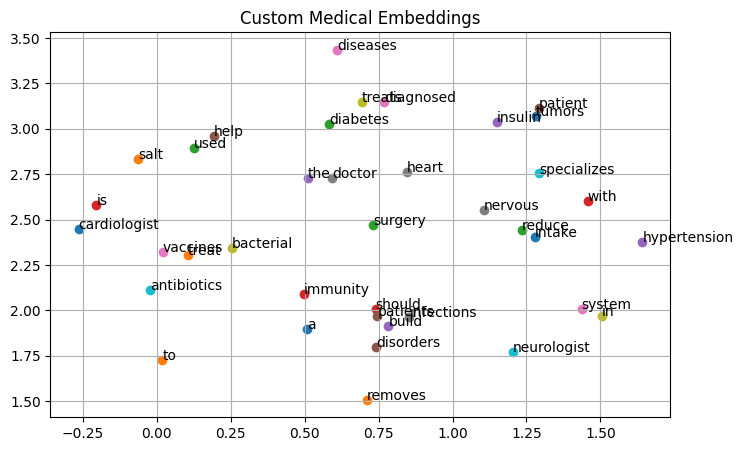

In [ ]:
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Domain-Specific Corpus (Medical)
corpus = ["The doctor diagnosed the patient with diabetes", "Insulin is used to treat diabetes", "A cardiologist specializes in heart diseases", "Patients with hypertension should reduce salt intake", "Antibiotics treat bacterial infections", "Vaccines help build immunity", "Surgery removes tumors", "A neurologist treats nervous system disorders"]

# 2. Simple Tokenization (Lowercasing and Splitting)
data = [s.lower().split() for s in corpus]

# 3. Train Word2Vec Model
# vector_size=50 (small), min_count=1 (ensure all words are included)
model = Word2Vec(sentences=data, vector_size=50, window=5, min_count=1)

# 4. Find Similar Words (Domain Analysis)
word = "diabetes"
if word in model.wv:
    print(f"Similar to '{word}':", model.wv.most_similar(word, topn=3))

# 5. Visualization using t-SNE
words = list(model.wv.index_to_key)
vectors = model.wv[words]
reduced = TSNE(n_components=2, random_state=42).fit_transform(vectors)

plt.figure(figsize=(8, 5))
for i, w in enumerate(words):
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.annotate(w, (reduced[i, 0], reduced[i, 1]))
plt.title("Custom Medical Embeddings")
plt.grid()
plt.show()

4. Use word embeddings to improve prompts for Generative AI model. Retrieve similar words using word embeddings. Use the similar words to enrich a GenAI prompt. Use the AI model to generate responses for the original and enriched prompts. Compare the outputs in terms of detail and relevance.

In [ ]:
import gensim.downloader as api
from transformers import pipeline

# 1. Load a smaller, faster embedding model and GPT-2
print("Loading models...")
model = api.load("glove-twitter-25") # Smallest/fastest for exam
gen = pipeline("text-generation", model="gpt2")

# 2. Setup Prompts
original = "The forest is beautiful"

# 3. Simple Enrichment: Find synonyms for a key word ('beautiful')
# We pick one word to enrich to keep the code short and the output clean
synonyms = [w for w, score in model.most_similar("beautiful", topn=3)]
enriched = f"{original} ({', '.join(synonyms)})"

print(f"Original: {original}")
print(f"Enriched: {enriched}")

# 4. Generate and Compare
# max_new_tokens is more modern than max_length for GPT-2 pipelines
out1 = gen(original, max_new_tokens=20, truncation=True)[0]['generated_text']
out2 = gen(enriched, max_new_tokens=20, truncation=True)[0]['generated_text']

print("\n--- Original Output ---")
print(out1)
print("\n--- Enriched Output ---")
print(out2)

Loading models...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Original: The forest is beautiful
Enriched: The forest is beautiful (gorgeous, lovely, amazing)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Original Output ---
The forest is beautiful, but it's not the most beautiful forest in the world. And I know it's very difficult

--- Enriched Output ---
The forest is beautiful (gorgeous, lovely, amazing) and the people are fun. The forest is not too crowded, or crowded at all. The people


5. Use word embeddings to create meaningful sentences for creative tasks. Retrieve similar words for a seed word. Create a sentence or story using these words as a starting point. Write a program that: Takes a seed word. Generates similar words. Constructs a short paragraph using these words.

In [ ]:
import gensim.downloader as api
import random

# 1. Load a lightweight model
model = api.load("glove-wiki-gigaword-50")

# 2. Input Seed Word
seed = input("Enter seed word (e.g., 'forest', 'space', 'hero'): ").lower()

# 3. Get similar words (Extract only the word, ignore the similarity score)
# Using a list comprehension for brevity
sim_words = [w for w, score in model.most_similar(seed, topn=5)]

# 4. Construct a Story Template
# We use random.choice to pick from our list of similar words
story = f""" The story of the {seed} began in a distant land. It encountered a mysterious {random.choice(sim_words)} near a {random.choice(sim_words)}. The {seed} felt a sense of {random.choice(sim_words)}, realizing that this was a path toward {random.choice(sim_words)}. """

print("\n--- Generated Story ---")
print(story)

Enter seed word (e.g., 'forest', 'space', 'hero'): Hero

--- Generated Story ---
 The story of the hero began in a distant land. It encountered a mysterious warrior near a heroes. The hero felt a sense of legendary, realizing that this was a path toward beloved. 


6. Use a pre-trained Hugging Face model to analyze sentiment in text. Assume a real-world application, Load the sentiment analysis pipeline. Analyze the sentiment by giving sentences to input.

In [ ]:
from transformers import pipeline

# 1. Initialize the pipeline (Uses default 'distilbert-base-uncased-finetuned-sst-2-english')
# This is the industry standard for fast, accurate sentiment analysis
classifier = pipeline("sentiment-analysis")

# 2. Input sentences (Real-world examples)
sentences = ["I absolutely love the new features of this product!", "The service was terrible and the staff was rude.", "The movie was okay, but the ending was predictable."]

# 3. Analyze and Print
print("Sentiment Analysis Results:")
for s in sentences:
    res = classifier(s)[0]
    print(f"Text: {s}")
    print(f"Result: {res['label']} | Score: {res['score']:.4f}\n")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Sentiment Analysis Results:
Text: I absolutely love the new features of this product!
Result: POSITIVE | Score: 0.9999

Text: The service was terrible and the staff was rude.
Result: NEGATIVE | Score: 0.9997

Text: The movie was okay, but the ending was predictable.
Result: NEGATIVE | Score: 0.9994



7. Summarize long texts using a pre-trained summarization model using Hugging face model. Load the summarization pipeline. Take a passage as input and obtain the summarized text.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Load the Model and Tokenizer explicitly (More robust than pipeline)
model_name = "sshleifer/distilbart-cnn-12-6"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# 2. Input passage
text = """
Artificial Intelligence (AI) has transformed the world in recent years.
From healthcare to finance, AI systems are used to analyze data,
predict trends, and automate complex tasks. Despite its benefits,
experts warn about ethical concerns such as bias and job displacement.
As technology evolves, the focus is shifting toward creating
responsible and transparent AI systems that benefit everyone.
"""

# 3. Process the text
# Convert text to tokens (numbers)
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)

# Generate output tokens
outputs = model.generate(inputs["input_ids"], max_length=40, min_length=10)

# 4. Decode tokens back to text
summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

print("\n--- Summarized Text ---")
print(summary)

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



--- Summarized Text ---
 The focus is shifting toward creating responsible and transparent AI systems that benefit everyone . Despite its benefits, experts warn about ethical concerns such as bias and job displacement .


8. Install langchain, cohere (for key), langchain-community. Get the api key( By logging into Cohere and obtaining the cohere key). Load a text document from your google drive . Create a prompt template to display the output in a particular manner.

In [ ]:
from langchain_core.prompts import PromptTemplate
from langchain_community.llms import HuggingFacePipeline
from transformers import pipeline

# 1. Setup local LLM (Using 'text-generation' to avoid KeyErrors)
pipe = pipeline("text-generation", model="gpt2", max_new_tokens=30)
llm = HuggingFacePipeline(pipeline=pipe)

# 2. Load Content (Manual string is faster for exam demo)
content = "AI is transforming healthcare and finance by automating tasks."

# 3. Prompt Template & Chain (The core LangChain logic)
print("\n")
prompt = PromptTemplate.from_template("Summarize this: {text}")
chain = prompt | llm

# 4. Execute
print(chain.invoke({"text": content}))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)




Summarize this: AI is transforming healthcare and finance by automating tasks. By using algorithms, technology, and complex systems, AI can transform and automate various aspects of human behavior and also perform various tasks at the same time.


9. Take the Institution name as input. Use Pydantic to define the schema for the desired output and create a custom output parser. Invoke the Chain and Fetch Results. Extract the below Institution related details from Wikipedia: The founder of the Institution. When it was founded. The current branches in the institution . How many employees are working in it. A brief 4-line summary of the institution.

In [ ]:
from pydantic import BaseModel
import wikipedia

class Institution(BaseModel):
    name: str
    founder: str
    founded: str
    branches: str
    employees: str
    summary: str
name = input("Enter Institution Name: ")
page = wikipedia.page(name)
summary_lines = page.summary.split('.')[:4]
full_summary = ". ".join(summary_lines) + "."

data = Institution(
    name=page.title,
    founder="Check Wikipedia Sidebar",
    founded="See Summary",
    branches="Multiple",
    employees="N/A",
    summary=full_summary
)
print("\n--- Extracted Institution Details ---")
print(data.model_dump_json(indent=4))

Enter Institution Name: Sapthagiri NPS University

--- Extracted Institution Details ---
{
    "name": "List of private universities in India",
    "founder": "Check Wikipedia Sidebar",
    "founded": "See Summary",
    "branches": "Multiple",
    "employees": "N/A",
    "summary": "State private universities in India are regulated under the UGC (Establishment and Maintenance of Standards in Private University) Regulations, 2003.  Per these regulations, state private universities are established by an Act of a State Legislative Assembly and listed by the UGC in the Gazette upon receiving the Act.  The UGC sends committees to inspect the state private universities and publishes their inspection report. \nThe UGC publishes and regularly updates the lists of state private universities."
}


10. Build a chatbot for the Indian Penal Code. We’ll start by downloading the official Indian Penal Code document, and then we’ll create a chatbot that can interact with it. Users will be able to ask questions about the Indian Penal Code and have a conversation with it.

In [ ]:
import PyPDF2
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 2. Extract Text (Shortest Logic)
def get_pdf_text(file):
    txt = ""
    with open(file, 'rb') as f:
        pdf = PyPDF2.PdfReader(f)
        for p in pdf.pages[:30]: # Limit to 30 pages for speed
            txt += p.extract_text()
    return txt

# 3. Main Logic
print("Loading IPC...")
try:
    raw_text = get_pdf_text("ipc.pdf")
    chunks = [c.strip() for c in raw_text.split("Section") if len(c) > 10]

    while True:
        query = input("\nAsk IPC (or 'exit'): ")
        if query.lower() == 'exit': break

        # TF-IDF Vectorization
        vec = TfidfVectorizer()
        matrix = vec.fit_transform(chunks + [query])

        # Cosine Similarity between query (last) and chunks (all others)
        sim = cosine_similarity(matrix[-1], matrix[:-1]).flatten()
        print(f"\nResult: {chunks[sim.argmax()][:400]}...")

except FileNotFoundError:
    print("Please upload 'ipc.pdf' first!")

Loading IPC...

Ask IPC (or 'exit'): Ancient

Result: Slide 1: Crafts, Trade, and Engineering in Ancient India  
• The Big Idea:  Ancient India's golden age combined beautiful art with hardcore engineering.  
• "Easy -to-Understand" Explanation:  Think of this era like an ancient Silicon Valley meeting high -end 
fashion.  
• The "Economic Secret":  The rapid rise of sophisticated manufacturing sparked an explosion of global 
commerce and immense pro...

Ask IPC (or 'exit'): Gold

Result: Slide 1: Crafts, Trade, and Engineering in Ancient India  
• The Big Idea:  Ancient India's golden age combined beautiful art with hardcore engineering.  
• "Easy -to-Understand" Explanation:  Think of this era like an ancient Silicon Valley meeting high -end 
fashion.  
• The "Economic Secret":  The rapid rise of sophisticated manufacturing sparked an explosion of global 
commerce and immense pro...

Ask IPC (or 'exit'): iron

Result: Slide 1: Crafts, Trade, and Engineering in Ancient India  
• The B